# 📊 Análisis de Soporte al Cliente en Twitter

_Proyecto desarrollado como parte de mi formación en Ingeniería de Datos._

Este análisis explora 100,000 interacciones reales entre clientes y agentes de soporte en Twitter. Se aplican técnicas fundamentales de ingeniería y análisis de datos para entender:

- Cuándo y cómo se comunican los clientes.
- Cuáles son los patrones de actividad más frecuentes.
- Cuánto tiempo tardan en responder los agentes.
- Qué tono emocional tienen los mensajes (análisis de sentimiento).

### 🧰 Tecnologías utilizadas:
- **Python** (pandas, numpy)
- **Visualización:** matplotlib, seaborn
- **Procesamiento de texto:** textblob
- **Dataset:** [Customer Support on Twitter – Kaggle](https://www.kaggle.com/datasets/thoughtvector/customer-support-on-twitter)

Este notebook forma parte de mi portafolio personal para mostrar mi desarrollo en proyectos de análisis de datos aplicados a escenarios reales.


# Proyecto 1: Análisis de Soporte al Cliente en Twitter
## Se realiza limpieza, transformación, análisis exploratorio y visualizaciones para identificar patrones clave.

# ----------------------------------------------
# 1. Importación de librerías
# ----------------------------------------------


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer





In [2]:
# Configuración gráfica
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
warnings.filterwarnings("ignore", category=FutureWarning)

# ----------------------------------------------
# 2. Carga de datos
# ----------------------------------------------

In [3]:
# Cargamos el archivo de muestra (ya preparado y limpio de Kaggle)
df_sample = pd.read_csv('twcs_sample_100k.csv')
df_sample['created_at'] = pd.to_datetime(df_sample['created_at'], errors='coerce')


In [4]:
print(df_sample.shape)
print("Vista previa del dataset:")
display(df_sample.head())

# Validamos si hay nombres de columnas esperados
expected_cols = ['tweet_id', 'author_id', 'inbound', 'created_at', 'text']
for col in expected_cols:
    if col not in df_sample.columns:
        print(f"⚠️ Advertencia: la columna '{col}' no está presente en el dataset.")

(100000, 7)
Vista previa del dataset:


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,192624,161253,True,2017-10-04 13:59:33+00:00,@161252 What's that egg website people talk about,192623,192625.0
1,738238,296574,True,2017-10-06 18:29:06+00:00,Why!🤷🏻‍♀️ #iOS11 @AppleSupport https://t.co/BX...,738237,NaN
2,2414302,AppleSupport,False,2017-11-14 17:38:01+00:00,@693975 We can assist you. We recommend updati...,2414303,2414304.0
3,1793929,539096,True,2017-10-12 06:04:41+00:00,@331912 @115955 Thats better than having an un...,1793928,1793930.0
4,2088018,617376,True,2017-11-06 20:30:49+00:00,@VirginAmerica is probably one of the best air...,2088017,NaN


# ----------------------------------------------
# 3. Descripción inicial del dataset
# ----------------------------------------------

## Columnas clave:
#### - tweet_id: identificador del mensaje
#### - author_id: identificador del usuario o agente
#### - created_at: fecha y hora del mensaje
#### - text: contenido textual del mensaje
#### - response_tweet_id: tweet al que responde (si aplica)


In [5]:
# Verificamos los nombres de columnas disponibles
df_sample.columns

Index(['tweet_id', 'author_id', 'inbound', 'created_at', 'text',
       'response_tweet_id', 'in_response_to_tweet_id'],
      dtype='object')

# ----------------------------------------------
# 4. Limpieza de datos
# ----------------------------------------------

In [6]:
def clean_data(df):
    """
    Elimina filas sin fecha ni texto y duplicados.
    """
    df = df.dropna(subset=['created_at', 'text'])
    df = df[df['text'].str.strip() != '']
    df = df.drop_duplicates()
    return df

In [7]:
# Revisión rápida de valores nulos por columna
print("Valores nulos por columna:")
print(df_sample.isnull().sum())

Valores nulos por columna:
tweet_id                       0
author_id                      0
inbound                        0
created_at                     0
text                           0
response_tweet_id          36835
in_response_to_tweet_id    28403
dtype: int64


In [8]:
# Aplicamos limpieza
df_sample = clean_data(df_sample)

# ----------------------------------------------
# 5. Transformación de datos
# ----------------------------------------------

In [9]:
# Creamos un diccionario para facilitar el análisis de tiempo de respuesta entre mensajes
# Clave: tweet_id, Valor: created_at
id_to_time = dict(zip(df_sample['tweet_id'], df_sample['created_at']))

def transform_data(df):
    """
    Agrega columnas derivadas para análisis: fecha, hora, día de la semana, tipo de autor,
    y calcula el tiempo de respuesta si aplica.
    """
    df['date'] = df['created_at'].dt.date
    df['hour'] = df['created_at'].dt.hour
    df['weekday'] = df['created_at'].dt.day_name()
    df['author_type'] = df['inbound'].apply(lambda x: 'Customer' if x else 'Agent')

    df['response_time_minutes'] = df.apply(
        lambda row: (row['created_at'] - id_to_time[row['in_response_to_tweet_id']]).total_seconds() / 60
        if pd.notnull(row['in_response_to_tweet_id']) and row['in_response_to_tweet_id'] in id_to_time else np.nan,
        axis=1
    )

    return df


In [10]:
# Transformamos datos
df_sample = transform_data(df_sample)

## Eliminación de valores infinitos

En este paso reemplazamos cualquier valor `inf` o `-inf` en el dataset por `NaN`, para evitar errores en los análisis o visualizaciones posteriores.


In [11]:
# Eliminamos posibles infinitos
df_sample.replace([np.inf, -np.inf], np.nan, inplace=True)

# ----------------------------------------------
# 5b. Análisis de sentimiento
# ----------------------------------------------

In [12]:
sia = SentimentIntensityAnalyzer()

# Función para obtener todos los scores de VADER
def get_vader_scores(text):
    if isinstance(text, str) and text.strip():
        return sia.polarity_scores(text)
    else:
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

In [13]:
# Aplicar análisis de sentimiento
df_sample['vader_scores'] = df_sample['text'].apply(get_vader_scores)
df_sample['vader_compound'] = df_sample['vader_scores'].apply(lambda s: s['compound'])

In [14]:
# Clasificación de sentimiento basado en VADER
def classify_vader_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'Positivo'
    elif compound_score <= -0.05:
        return 'Negativo'
    else:
        return 'Neutral'

In [15]:
# Aplicar la clasificación
df_sample['sentiment_label'] = df_sample['vader_compound'].apply(classify_vader_sentiment)
def clasificar_sentimiento(polaridad):
    if pd.isnull(polaridad):
        return np.nan
    elif polaridad > 0.1:
        return 'Positivo'
    elif polaridad < -0.1:
        return 'Negativo'
    else:
        return 'Neutral'

# ----------------------------------------------
# 6. Análisis exploratorio
# ----------------------------------------------

In [16]:
def analyze_data(df):
    """
    Muestra estadísticas básicas del dataset.
    """
    total = len(df)
    clientes = df['inbound'].sum()
    agentes = total - clientes

    print(f"Total de mensajes: {total}")
    print(f"Mensajes de clientes: {clientes}")
    print(f"Mensajes de agentes: {agentes}")
    print("\nTop 5 días con más mensajes:")
    print(df['date'].value_counts().head())
    print("\nMensajes por día de la semana:")
    print(df['weekday'].value_counts())
    print("\nMensajes por hora del día:")
    print(df['hour'].value_counts().sort_index())


In [17]:
# Ejecutar análisis
analyze_data(df_sample)

Total de mensajes: 100000
Mensajes de clientes: 54693
Mensajes de agentes: 45307

Top 5 días con más mensajes:
date
2017-11-07    2174
2017-10-27    2146
2017-11-08    2069
2017-11-03    2068
2017-11-29    1991
Name: count, dtype: int64

Mensajes por día de la semana:
weekday
Friday       16230
Wednesday    16120
Thursday     15651
Tuesday      15046
Monday       13733
Saturday     11722
Sunday       11498
Name: count, dtype: int64

Mensajes por hora del día:
hour
0     4022
1     3770
2     3560
3     3145
4     2737
5     2503
6     2391
7     2750
8     2865
9     2907
10    3100
11    3235
12    3889
13    4600
14    5184
15    5550
16    5922
17    6203
18    5911
19    5743
20    5487
21    5271
22    4898
23    4357
Name: count, dtype: int64


In [18]:
# Métricas de calidad del servicio
respuestas_rapidas = df_sample[df_sample['response_time_minutes'] < 60]
porcentaje_respuestas_rapidas = len(respuestas_rapidas) / df_sample['response_time_minutes'].notna().sum() * 100
print(f"Porcentaje de respuestas menores a 1 hora: {porcentaje_respuestas_rapidas:.2f}%")

negativos_lentos = df_sample[(df_sample['sentiment_label'] == 'Negativo') & (df_sample['response_time_minutes'] > 60)]
total_negativos = df_sample[df_sample['sentiment_label'] == 'Negativo'].shape[0]
porcentaje_negativos_lentos = (len(negativos_lentos) / total_negativos * 100) if total_negativos > 0 else 0
print(f"% de mensajes negativos con tiempo de respuesta mayor a 1 hora: {porcentaje_negativos_lentos:.2f}%")

Porcentaje de respuestas menores a 1 hora: 68.09%
% de mensajes negativos con tiempo de respuesta mayor a 1 hora: 0.57%


In [19]:
# Tiempo promedio de respuesta solo para mensajes negativos
negativos = df_sample[df_sample['sentiment_label'] == 'Negativo']
if not negativos.empty:
    print("Tiempo promedio de respuesta (solo negativos):", negativos['response_time_minutes'].mean())
    print("Clientes con más mensajes negativos:")
    print(negativos['author_id'].value_counts().head())

Tiempo promedio de respuesta (solo negativos): 1193.6171524663678
Clientes con más mensajes negativos:
author_id
AmazonHelp         1151
British_Airways     260
Uber_Support        259
GWRHelp             230
Delta               230
Name: count, dtype: int64


In [20]:
# Estadísticas del tiempo de respuesta
print("Tiempo promedio de respuesta (minutos):", df_sample['response_time_minutes'].mean())
print("Mediana del tiempo de respuesta (minutos):", df_sample['response_time_minutes'].median())
print("Desviación estándar del tiempo de respuesta:", df_sample['response_time_minutes'].std())


Tiempo promedio de respuesta (minutos): 1668.3217137551399
Mediana del tiempo de respuesta (minutos): 19.4
Desviación estándar del tiempo de respuesta: 27843.565920926092


### Distribución del Tiempo de Respuesta con Escala Logarítmica

La siguiente visualización utiliza una escala logarítmica en el eje X para representar adecuadamente la gran variabilidad en los tiempos de respuesta, sin eliminar valores extremos:

- El eje X (minutos) avanza en potencias de 10: 1, 10, 100, 1,000...
- Esto permite observar respuestas rápidas (1–10 minutos) y también tiempos largos (días o semanas).
- La mayoría de los tweets son respondidos entre 1 y 100 minutos.
- Valores extremos aparecen como una “cola” hacia la derecha, representando menos frecuencia.

Este tipo de gráfica es ideal cuando existen valores atípicos que distorsionan las distribuciones lineales.

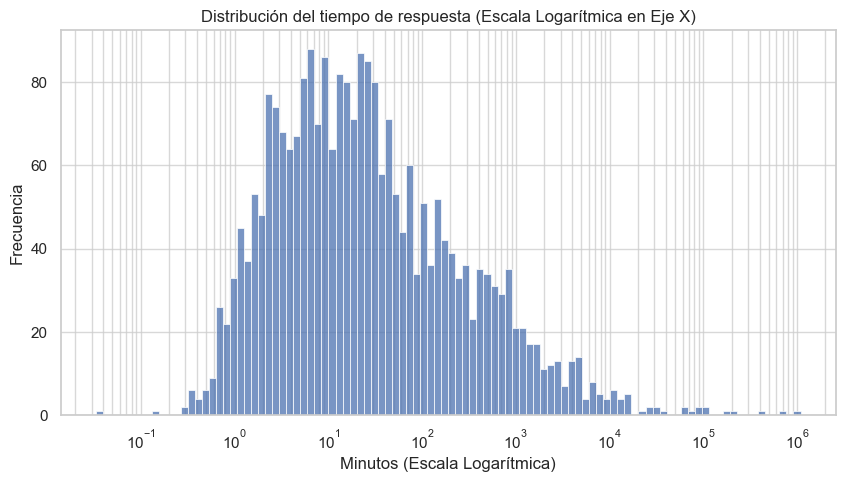

In [21]:

# 1. Grafica el histograma usando el DataFrame original
plt.figure(figsize=(10, 5)) # Ajusta el tamaño

sns.histplot(df_sample['response_time_minutes'], bins=100, kde=False, log_scale=True)

plt.title("Distribución del tiempo de respuesta (Escala Logarítmica en Eje X)")
plt.xlabel("Minutos (Escala Logarítmica)") # Indica que el eje está en escala log
plt.ylabel("Frecuencia")

plt.grid(axis='y', alpha=0.75)
plt.grid(axis='x', alpha=0.75, which='both') # Mostrar grid en ambos ejes para escala log
plt.show()


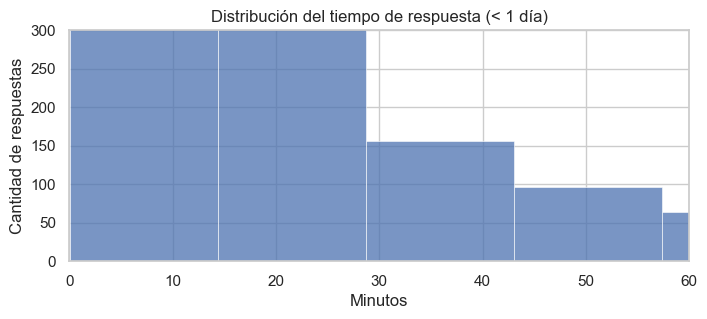

In [22]:
# Filtrado de valores normales (< 1 día)
normal = df_sample[df_sample['response_time_minutes'] < 1440]

# Visualización de la distribución original
plt.figure(figsize=(8, 3))
sns.histplot(normal['response_time_minutes'], bins=100)
plt.title("Distribución del tiempo de respuesta (< 1 día)")
plt.xlabel("Minutos")
plt.ylabel("Cantidad de respuestas")
plt.xlim(0, 60)
plt.ylim(0, 300)
plt.show()

In [23]:
# Análisis de valores atípicos
outliers = df_sample[df_sample['response_time_minutes'] > 1440]
print("Mensajes con respuesta mayor a 1 día:", len(outliers))
print("Tiempo de respuesta máximo (días):", df_sample['response_time_minutes'].max() / 1440)

Mensajes con respuesta mayor a 1 día: 145
Tiempo de respuesta máximo (días): 753.1709374999999


In [24]:
# Validación de outliers: ¿hay algún patrón o error en las fechas?
print("Ejemplos de valores extremos:")
print(outliers[['author_id', 'created_at', 'in_response_to_tweet_id', 'response_time_minutes']].sort_values(by='response_time_minutes', ascending=False).head())

Ejemplos de valores extremos:
      author_id                created_at  in_response_to_tweet_id  \
48643    293527 2017-10-10 20:49:21+00:00                 424204.0   
39260    341440 2017-10-05 20:11:25+00:00                 933525.0   
55609    378775 2017-11-06 06:57:42+00:00                1651449.0   
23579    383089 2017-10-24 08:41:07+00:00                1114800.0   
19807    532407 2017-11-17 12:11:52+00:00                1771166.0   

       response_time_minutes  
48643           1.084566e+06  
39260           6.839662e+05  
55609           4.239647e+05  
23579           1.959359e+05  
19807           1.712271e+05  


In [25]:
# Filtrado de valores normales (< 1 día)
normal = df_sample[df_sample['response_time_minutes'] < 1440]
print("Media (sin outliers):", normal['response_time_minutes'].mean())
print("Mediana (sin outliers):", normal['response_time_minutes'].median())
print("Desviación estándar (sin outliers):", normal['response_time_minutes'].std())

Media (sin outliers): 107.29391188063063
Mediana (sin outliers): 16.608333333333334
Desviación estándar (sin outliers): 228.66836595265116


# ----------------------------------------------
# 7. Visualización de datos
# ----------------------------------------------

In [26]:

def visualize_data(df):
    """
    Crea gráficos para entender los patrones de actividad.
    También ajusta el tamaño de cada figura para evitar scroll vertical.
    """
    # Distribución por tipo de autor
    plt.figure(figsize=(8, 4))
    sns.countplot(x='author_type', data=df, palette='Set2')
    plt.title("Distribución de mensajes por tipo de autor")
    plt.xlabel("Tipo de autor")
    plt.ylabel("Cantidad de mensajes")
    plt.show()

    # Distribución de mensajes por hora del día
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x='hour', hue='author_type', multiple='stack', bins=24, palette='viridis')
    plt.title("Distribución de mensajes por hora")
    plt.xlabel("Hora del día")
    plt.ylabel("Cantidad de mensajes")
    plt.show()

    # Actividad por día de la semana
    order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    plt.figure(figsize=(10, 4))
    sns.countplot(x='weekday', data=df, order=order, palette='coolwarm')
    plt.title("Mensajes por día de la semana")
    plt.xlabel("Día")
    plt.ylabel("Cantidad de mensajes")
    plt.xticks(rotation=45)
    plt.show()


    # Mapa de calor de actividad por hora y día
    #heatmap_data = df.groupby(['weekday', 'hour']).size().unstack().reindex(index=order)
    heatmap_data = df.groupby(['weekday', 'hour']).size().unstack().reindex(index=order).fillna(0)

    plt.figure(figsize=(10, 6))
    sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=.5, annot=False)
    plt.title("Mapa de calor de actividad por hora y día")
    plt.xlabel("Hora del día")
    plt.ylabel("Día de la semana")
    plt.show()


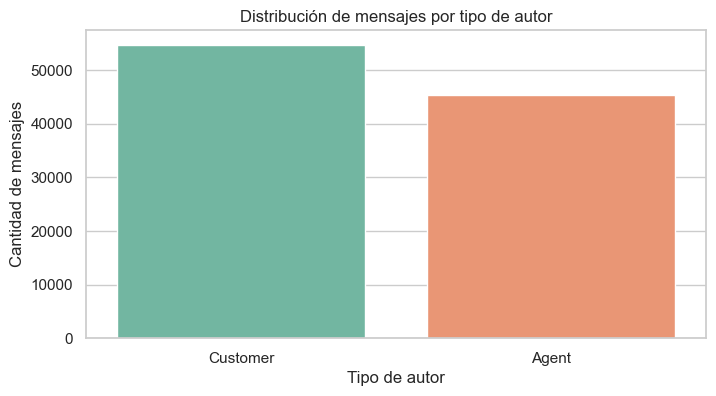

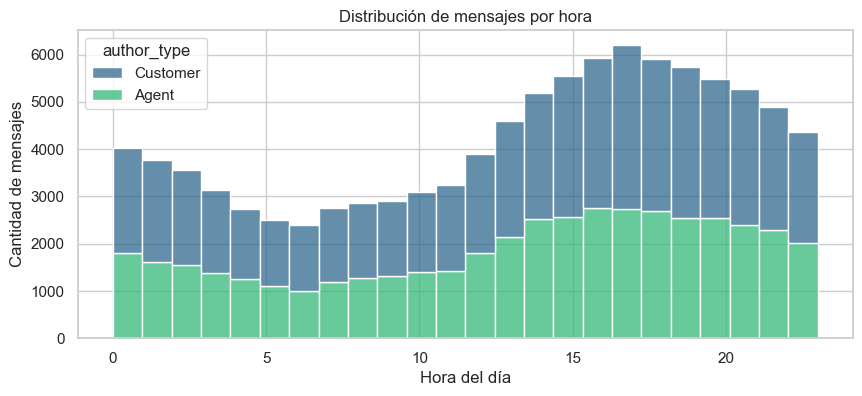

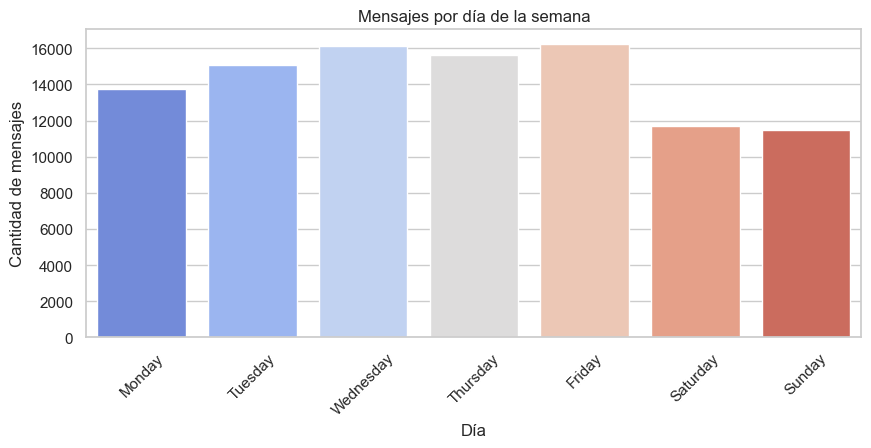

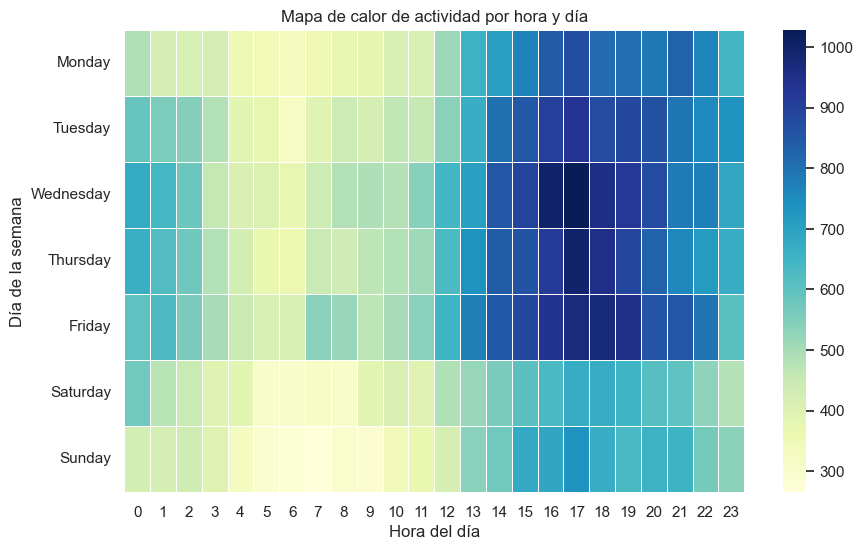

In [27]:
# Ejecutar visualizaciones
visualize_data(df_sample)


In [28]:
# Análisis de sentimiento
# Verificamos cuántos mensajes de clientes fueron procesados
clientes = df_sample[df_sample['author_type'] == 'Customer']
analizados = clientes['sentiment_label'].notna().sum()
print(f"Total de mensajes de clientes: {len(clientes)}")
print(f"Mensajes con sentimiento calculado: {analizados}")

print("Distribución del sentimiento de los mensajes de clientes:")
print(df_sample['sentiment_label'].value_counts())


Total de mensajes de clientes: 54693
Mensajes con sentimiento calculado: 54693
Distribución del sentimiento de los mensajes de clientes:
sentiment_label
Positivo    50621
Neutral     26097
Negativo    23282
Name: count, dtype: int64


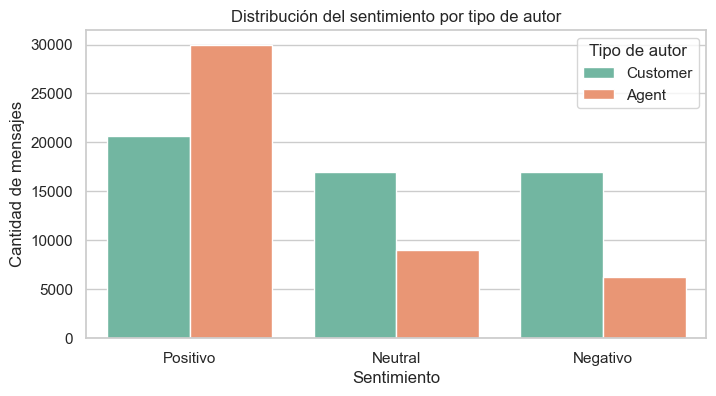

In [29]:
# Visualización de la distribución del sentimiento

# Comparativa de sentimiento por tipo de autor
plt.figure(figsize=(8, 4))
sns.countplot(x='sentiment_label', hue='author_type', data=df_sample, order=['Positivo', 'Neutral', 'Negativo'], palette='Set2')
plt.title("Distribución del sentimiento por tipo de autor")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de mensajes")
plt.legend(title='Tipo de autor')
plt.show()

Positivo: 50621 mensajes


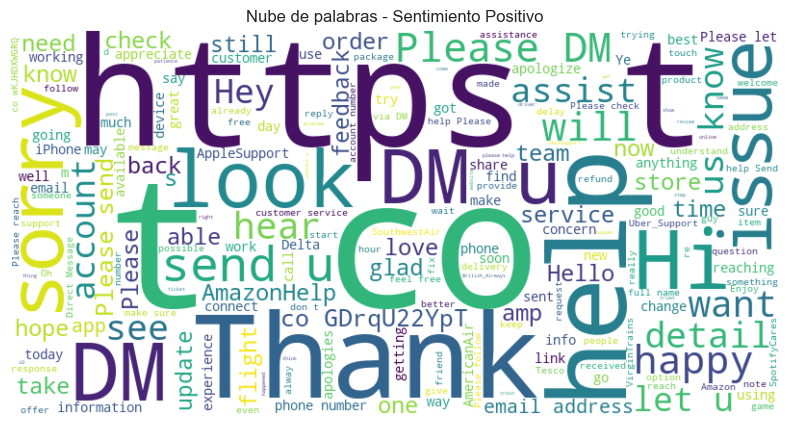

Neutral: 26097 mensajes


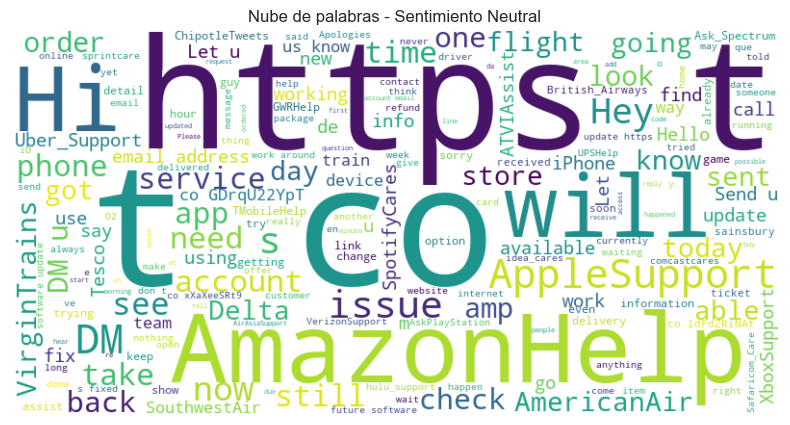

Negativo: 23282 mensajes


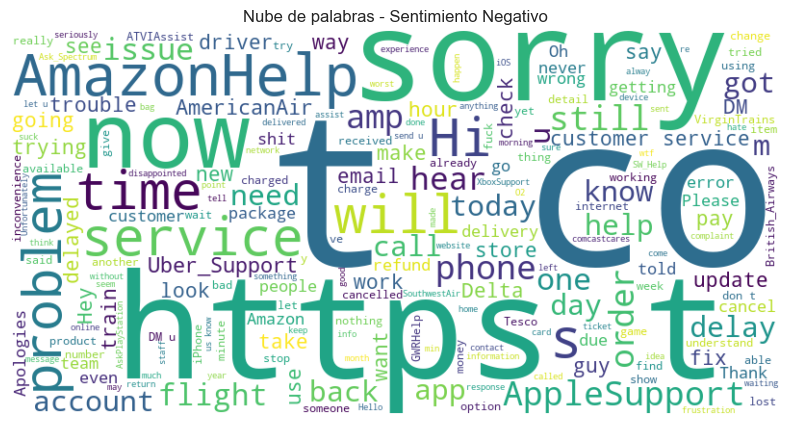

In [30]:
# Nube de palabras por tipo de sentimiento
from wordcloud import WordCloud

for label in ['Positivo', 'Neutral', 'Negativo']:
    mensajes = df_sample[df_sample['sentiment_label'] == label]['text']
    print(f"{label}: {mensajes.shape[0]} mensajes")
    textos = ' '.join(mensajes.dropna().astype(str))
    if textos:
        wc = WordCloud(width=800, height=400, background_color='white').generate(textos)
        plt.figure(figsize=(10, 5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Nube de palabras - Sentimiento {label}")
        plt.show()


In [31]:
# Top autores más activos
print("Top 10 autores con más mensajes:\n")
print(df_sample['author_id'].value_counts().head(10))

Top 10 autores con más mensajes:

author_id
AmazonHelp      6046
AppleSupport    3773
Uber_Support    1968
SpotifyCares    1561
Delta           1557
Tesco           1335
AmericanAir     1310
TMobileHelp     1253
comcastcares    1157
SouthwestAir    1057
Name: count, dtype: int64


In [32]:
# Sesiones de conversación por usuario (con ventana de 30 minutos)
df_sample = df_sample.sort_values(['author_id', 'created_at'])
df_sample['session_gap'] = df_sample.groupby('author_id')['created_at'].diff().dt.total_seconds().div(60)
df_sample['new_session'] = df_sample['session_gap'] > 30

df_sample['session_id'] = df_sample.groupby('author_id')['new_session'].cumsum()
sesiones = df_sample.groupby(['author_id', 'session_id']).size().reset_index(name='mensajes_por_sesion')


In [33]:
# Mostrar resumen de sesiones
print("Cantidad total de sesiones:", sesiones.shape[0],"\n")
print("Media de mensajes por sesión:", sesiones['mensajes_por_sesion'].mean())
print(sesiones.head())

Cantidad total de sesiones: 78912 

Media de mensajes por sesión: 1.267234387672344
  author_id  session_id  mensajes_por_sesion
0     10103           0                    1
1    115714           0                    1
2    115714           1                    1
3    115714           2                    1
4    115714           3                    1


Top 10 sesiones más largas con sus autores y con más mensajes:

          author_id  session_id  mensajes_por_sesion
57693  AppleSupport         307                  137
57690  AppleSupport         304                  106
56580    AmazonHelp         722                   82
56341    AmazonHelp         483                   80
57686  AppleSupport         300                   79
56587    AmazonHelp         729                   66
57664  AppleSupport         278                   62
56333    AmazonHelp         475                   62
57673  AppleSupport         287                   60
73424  Uber_Support         630                   60


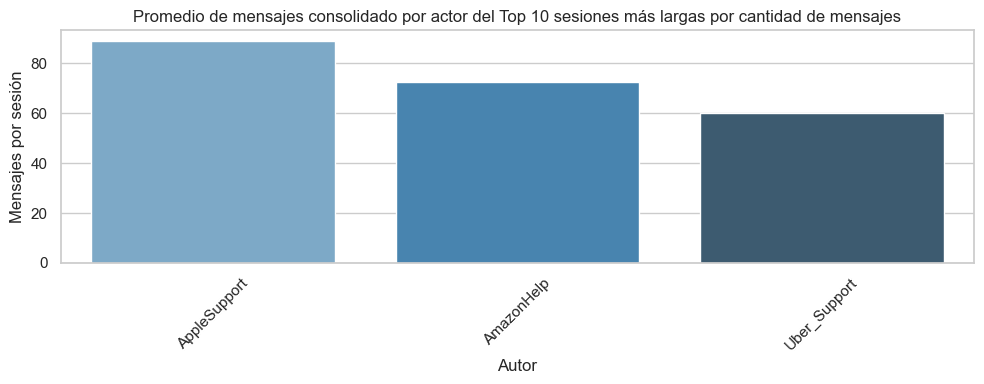

In [34]:
# Visualización de sesiones más largas
print("Top 10 sesiones más largas con sus autores y con más mensajes:\n")
top_sesiones = sesiones.sort_values(by='mensajes_por_sesion', ascending=False).head(10)
print(top_sesiones)

# Gráfico de sesiones más largas
plt.figure(figsize=(10, 4))
sns.barplot(x='author_id', y='mensajes_por_sesion', data=top_sesiones, palette='Blues_d', ci=None)
plt.title("Promedio de mensajes consolidado por actor del Top 10 sesiones más largas por cantidad de mensajes")
plt.xlabel("Autor")
plt.ylabel("Mensajes por sesión")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [35]:
# Exportación de resultados clave

# Guardar sesiones y sentimientos a CSV
sesiones.to_csv("resumen_sesiones.csv", index=False)
df_sample[['author_id', 'created_at', 'text', 'sentiment_label', 'response_time_minutes']].to_csv("resumen_sentimiento.csv", index=False)

# ----------------------------------------------
# 8. Conclusiones
# ----------------------------------------------
Este proyecto permite explorar patrones clave en la atención al cliente por Twitter a través del análisis de interacciones entre usuarios y agentes. A partir del procesamiento de una muestra representativa de datos, se identifican horarios pico, tipos de usuario y distribución semanal de la actividad.

También se identificaron **145 casos con tiempos de respuesta superiores a 1 día**, algunos incluso con demoras de más de **750 días**. Estos valores atípicos inflaban la media general de respuesta (~27 horas), pero una vez filtrados, los datos reflejan un comportamiento mucho más operativo:
- **Media real**: ~1.8 horas
- **Mediana**: ~16 minutos
- **Desviación estándar**: ~3.8 horas

Este análisis puede extenderse para:
- Calcular tiempos de respuesta entre cliente y agente con mayor precisión.
- Incorporar análisis de sentimiento sobre el contenido de los mensajes.
- Integrarse en dashboards interactivos para monitoreo en tiempo real.

Además, los resultados permiten:
- Detectar clientes con múltiples mensajes negativos, lo cual puede alimentar modelos de predicción de cancelación o insatisfacción (churn).
- Establecer reglas automáticas para priorizar atención rápida a clientes críticos.
- Entrenar bots de atención que identifiquen urgencia basada en sentimiento y contexto..
